Task 3: Deep Learning Modelling and Evaluation (50 Marks)

First I import needed libaries

In [92]:
# %pip install ImageHash
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import os
import imagehash
import hashlib
from collections import defaultdict
import pandas as pd
from collections import Counter
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

Then I check the path to the dataset

In [93]:
DATASET_DIR = Path("../data/")

print("Dataset path:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset path: ..\data
Exists: True


So the datapath is good. I will check the number of classes in the dataset 

In [94]:
# identify the classes.

classes = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("\nClasses:")

for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

Number of classes: 2

Classes:
0: ve_negative
1: ve_positive


So the dataset has two classes ve_negative and ve_positibe as described in the assignment, so it is good. In the next step I create the dataframe so that I can get the inputs for the model

In [95]:
# Create an image metadata DataFrame

records = []

valid_extensions = {
    ".jpg", ".jpeg", ".png",
    ".tif", ".tiff", ".bmp"
}

for cls in classes:

    class_dir = DATASET_DIR / cls

    for image_path in class_dir.rglob("*"):

        if image_path.suffix.lower() not in valid_extensions:
            continue

        records.append({
            "path": str(image_path),
            "class": cls,
            "filename": image_path.name
        })

image_df = pd.DataFrame(records)



print("Total images:", len(image_df))

image_df.head()

Total images: 519


,path,class,filename
0,..\data\ve_negative\Biospatial_20160603U_1171_...,ve_negative,Biospatial_20160603U_1171_03_03.png
1,..\data\ve_negative\Biospatial_20160603U_1173_...,ve_negative,Biospatial_20160603U_1173_04_01.png
2,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_03.png
3,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_04.png
4,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_04_03.png


I create the load_images to load data for the inputs

In [96]:




def load_images(df, image_size=(64,64)):
    images = []
    labels = []
    i = 1
    for _, row in df.iloc[:len(df)].iterrows():

        img_path = row["path"]
        print(i) # To see the progress of loading.
        i=i+1
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, image_size)

        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(row["class"])

    return np.array(images), np.array(labels)

load_images(image_df)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


(array([[[[0.49411765, 0.54509807, 0.34509805],
          [0.6784314 , 0.58431375, 0.40784314],
          [0.47843137, 0.47843137, 0.32156864],
          ...,
          [0.41568628, 0.5137255 , 0.30980393],
          [0.40392157, 0.5019608 , 0.32156864],
          [0.41568628, 0.49411765, 0.3019608 ]],
 
         [[0.5568628 , 0.6       , 0.39607844],
          [0.49803922, 0.54901963, 0.3372549 ],
          [0.62352943, 0.61960787, 0.43529412],
          ...,
          [0.3019608 , 0.3882353 , 0.23529412],
          [0.35686275, 0.4392157 , 0.2784314 ],
          [0.3764706 , 0.4627451 , 0.28627452]],
 
         [[0.53333336, 0.58431375, 0.39215687],
          [0.4862745 , 0.54509807, 0.3254902 ],
          [0.57254905, 0.6039216 , 0.40392157],
          ...,
          [0.3647059 , 0.4392157 , 0.26666668],
          [0.36862746, 0.4509804 , 0.27450982],
          [0.42745098, 0.49019608, 0.32941177]],
 
         ...,
 
         [[0.69411767, 0.7019608 , 0.5019608 ],
          [0.56470

I will try load_images for the two inputs X and Y here 

In [97]:
X, y = load_images(image_df)
print("X shape:", X.shape)
print("y shape:", y.shape)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


I will import some other libraries that are needed to run the model 

In [98]:


import pandas as pd
import cv2
import numpy as np
from PIL import Image
import os
import tifffile as tiff

from skimage.transform import resize

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, 
    Flatten, 
    Conv2D, 
    BatchNormalization, 
    Activation, 
    MaxPooling2D, 
    GlobalAveragePooling2D, 
    Dense, 
    Dropout, 
    Add, 
    Concatenate
)

We split the dataset into train, test and val data. In this sone we use the see to make the data splitting fixed so that the results can be reproducible 

In [99]:

import random
import numpy as np
import tensorflow as tf
# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Splitting the dataset into three datasets for training, testing and validation with the ratio 60% : 20% : 20%
X_train, X_test_initial, y_train, y_test_initial = train_test_split(X, y, test_size=0.4, random_state=seed)
X_test, X_val, y_test, y_val = train_test_split(X_test_initial, y_test_initial, test_size=0.5, random_state=seed)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.fit_transform(y_val)
y_test_encoded = label_encoder.fit_transform(y_test)

I have a look at the shape of the train, val and test data 

In [100]:

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (311, 64, 64, 3)
y_train shape: (311,)
X_test shape: (104, 64, 64, 3)
y_test shape: (104,)
X_val shape: (104, 64, 64, 3)
y_val shape: (104,)


So we can see that the datashape of the test, train, and val data is good. In each of the data group, I want to have a look at the distribution of the classes to be sure  

In [101]:
import pandas as pd

print(pd.Series(y_train).value_counts())

print(pd.Series(y_test).value_counts())

print(pd.Series(y_val).value_counts())

ve_negative    168
ve_positive    143
Name: count, dtype: int64
ve_negative    62
ve_positive    42
Name: count, dtype: int64
ve_negative    57
ve_positive    47
Name: count, dtype: int64


So we can see that the classes are distributed quite equally within train, val and test data, so it is good. In the next step. I will run the first model: CNN

Model 1: Build the CNN Network

In [102]:
num_classes = len(np.unique(y_train))

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

model.summary()

C:\Users\vla\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,306 (4.98 MB)

 Trainable params: 1,306,306 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

In [103]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:

# Train

history_cnn = model.fit(
    X_train,
    y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=64,
    shuffle=True
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.4502 - loss: 0.7009 - val_accuracy: 0.5481 - val_loss: 0.6916
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5402 - loss: 0.6923 - val_accuracy: 0.5481 - val_loss: 0.6907
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5305 - loss: 0.6917 - val_accuracy: 0.5288 - val_loss: 0.6874
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5788 - loss: 0.6825 - val_accuracy: 0.5962 - val_loss: 0.6787
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6302 - loss: 0.6632 - val_accuracy: 0.6058 - val_loss: 0.6612
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6206 - loss: 0.6289 - val_accuracy: 0.6538 - val_loss: 0.6367
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6559 - loss: 0.5970 - val_accuracy: 0.6538 - val_loss: 0.6271
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7074 - loss: 0.5877 - val_accuracy: 0.6346 - val_loss: 0.6619

In [105]:
# Evaluate

test_loss, test_acc = model.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7692 - loss: 0.5527
Test Accuracy: 0.7692307829856873


In [106]:
# Predict
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])
print(y_test_encoded[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[1 1 1 1 1 0 1 1 0 1]
[1 1 0 1 1 0 1 1 0 1]


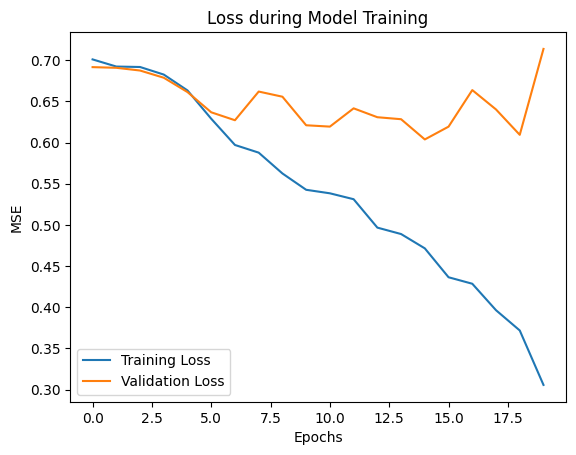

In [107]:
# Plot the training and validation accuracy and loss
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

So for this CNN Model, the accuracy is quite good even it is not too high. So I will fine tune some parameters of the model. I will try first with a differen set of batch size and epochs, I will try with batch size of 32 and epoches of 30


In [108]:
num_classes = len(np.unique(y_train))

model_1 = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

model_1.summary()

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_1 = model_1.fit(
    X_train,
    y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=30,
    batch_size=32,
    shuffle=True
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,306 (4.98 MB)

 Trainable params: 1,306,306 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.4759 - loss: 0.7061 - val_accuracy: 0.5481 - val_loss: 0.6913
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5209 - loss: 0.6951 - val_accuracy: 0.5481 - val_loss: 0.6889
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5273 - loss: 0.6871 - val_accuracy: 0.5481 - val_loss: 0.6837
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5627 - loss: 0.6708 - val_accuracy: 0.5577 - val_loss: 0.6820
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6367 - loss: 0.6525 - val_accuracy: 0.5577 - val_loss: 0.6723
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.6592 - loss: 0.6111 - val_accuracy: 0.6058 - val_loss: 0.6630
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6463 - loss: 0.6038 - val_accuracy: 0.6154 - val_loss: 0.6379
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6592 - loss: 0.5873 - val_accuracy: 0.5769 - 

We can see that the accuracy for trained data and val_data is higher but the loss for val_data is also higher, soe we might have overfitting for this model

In [109]:
test_loss_1, test_acc_1 = model_1.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6731 - loss: 1.4120
Test Accuracy: 0.6730769276618958


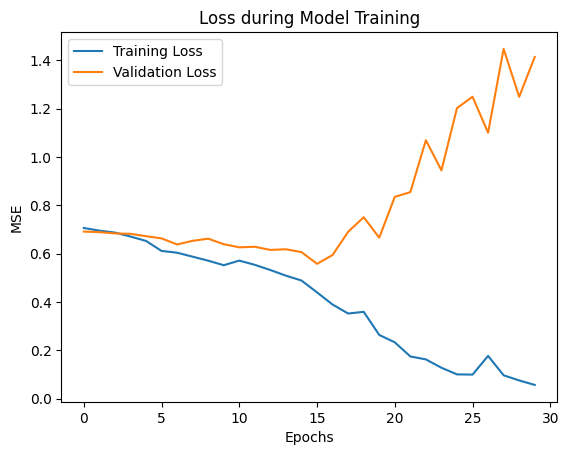

In [110]:
# Plot the training and validation accuracy and loss
plt.plot(history_cnn_1.history["loss"], label="Training Loss")
plt.plot(history_cnn_1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

 I will stay with the original model. Next first we try a different learning rate to 0.0001

In [111]:
from tensorflow.keras.optimizers import Adam
num_classes = len(np.unique(y_train))

model_2 = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

model_2.summary()

model_2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_2 = model_2.fit(
    X_train,
    y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=64,
    shuffle=True
)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,306 (4.98 MB)

 Trainable params: 1,306,306 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.5113 - loss: 0.6948 - val_accuracy: 0.4519 - val_loss: 0.6932
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5788 - loss: 0.6894 - val_accuracy: 0.5096 - val_loss: 0.6922
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5788 - loss: 0.6902 - val_accuracy: 0.5385 - val_loss: 0.6915
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5723 - loss: 0.6883 - val_accuracy: 0.5385 - val_loss: 0.6913
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5305 - loss: 0.6896 - val_accuracy: 0.5385 - val_loss: 0.6911
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5916 - loss: 0.6846 - val_accuracy: 0.4904 - val_loss: 0.6900
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5884 - loss: 0.6816 - val_accuracy: 0.5096 - val_loss: 0.6891
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6013 - loss: 0.6794 - val_accuracy: 0.5673 - val_loss:

In [112]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6635 - loss: 0.5964
Test Accuracy: 0.6634615659713745


So we can see that with the learning rate 0.0001 the accuracy is lower then with the default learning rate of Adam so I wll stay with the original model. To address the overfitting, we will try early stop 

In [113]:
import keras

from tensorflow.keras.optimizers import Adam
num_classes = len(np.unique(y_train))

model_3 = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_3.summary()

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_3 = model_3.fit(
    X_train,
    y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=64,
    shuffle=True,  callbacks=[early_stop]
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,306 (4.98 MB)

 Trainable params: 1,306,306 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.5016 - loss: 0.7593 - val_accuracy: 0.5481 - val_loss: 0.6948
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.5338 - loss: 0.6983 - val_accuracy: 0.5481 - val_loss: 0.6921
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.5305 - loss: 0.6923 - val_accuracy: 0.5385 - val_loss: 0.6911
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5756 - loss: 0.6856 - val_accuracy: 0.5481 - val_loss: 0.6921
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.5659 - loss: 0.6874 - val_accuracy: 0.5096 - val_loss: 0.6850
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6238 - loss: 0.6665 - val_accuracy: 0.5385 - val_loss: 0.6809
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6238 - loss: 0.6597 - val_accuracy: 0.5000 - val_loss: 0.6836
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6495 - loss: 0.6277 - val_accuracy: 0.5096 - val_loss:

In [114]:
test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7308 - loss: 0.5702
Test Accuracy: 0.7307692170143127


In this the accuracy is just a little lower than the original one and the loss little higher  so I will stay with the original model 

In the next step, I wil try data augmentation to see if the accuracy can increase more

In [115]:
num_classes = len(np.unique(y_train))

model_data_aug = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

model_data_aug.summary()

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.10,
    
)

train_generator = datagen.flow(
    X_train,
    y_train_encoded,
    batch_size=64,
    shuffle=True
)

model_data_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_data_aug = model_data_aug.fit(
    train_generator,
    validation_data=(X_val, y_val_encoded),
    epochs=20
    
    
)




Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,306 (4.98 MB)

 Trainable params: 1,306,306 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.5563 - loss: 0.7195 - val_accuracy: 0.5096 - val_loss: 0.6932
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5338 - loss: 0.6904 - val_accuracy: 0.5865 - val_loss: 0.6864
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.6238 - loss: 0.6771 - val_accuracy: 0.5577 - val_loss: 0.6737
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.6045 - loss: 0.6581 - val_accuracy: 0.5096 - val_loss: 0.7114
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.5916 - loss: 0.6570 - val_accuracy: 0.6058 - val_loss: 0.6836
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.6334 - loss: 0.6640 - val_accuracy: 0.5288 - val_loss: 0.7010
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.6849 - loss: 0.6149 - val_accuracy: 0.5673 - val_loss: 0.6624
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.6592 - loss: 0.6102 - val_accuracy: 0.5385 - val_loss:

In [116]:
test_loss_data_aug, test_acc_data_aug = model_data_aug.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_data_aug)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6635 - loss: 0.6028
Test Accuracy: 0.6634615659713745


So we can see that the model with data augmentaion gives us the the accuracy score is quite relatively lower than other model so for the CNN model, I will use the original model. In the next step, I will have the overall evaluation of this model. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Accuracy:  0.7692307692307693
Precision:  0.7779876373626373
Recall:  0.7692307692307693
F1 Score:  0.7710560625814863
ROC AUC Score:  0.8390937019969278


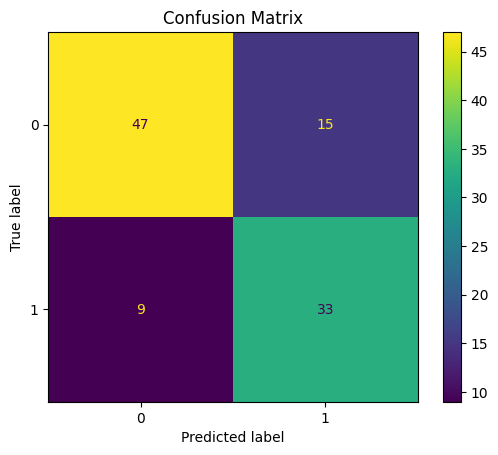

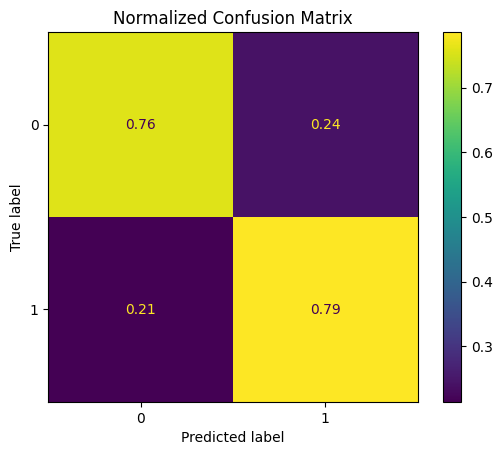

Log Loss:  0.5527244345334907


In [117]:
# Model predictions (probabilities)
Y_prob = model.predict(X_test)

# Convert one-hot → class labels
Y_test_labels = y_test_encoded
Y_pred = np.argmax(Y_prob, axis=1)

accuracy_model = accuracy_score(Y_test_labels, Y_pred)
precision_model = precision_score(Y_test_labels, Y_pred, average="weighted")
recall_score_model = recall_score(Y_test_labels, Y_pred, average="weighted")
f1_score_model = f1_score(Y_test_labels, Y_pred, average="weighted")

# Classification metrics (use labels)
print("Accuracy: ", accuracy_model)
print("Precision: ", precision_model)
print("Recall: ", recall_score_model)
print("F1 Score: ", f1_score_model)

# ROC AUC (multi-class, use probabilities)
roc_auc = roc_auc_score(
    y_test_encoded, 
    Y_prob[:,1]
)

print("ROC AUC Score: ", roc_auc)

# Confusion Matrix
cm = confusion_matrix(Y_test_labels, Y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    Y_test_labels,
    Y_pred,
    normalize="true"
)
plt.title("Normalized Confusion Matrix")
plt.show()
log_loss_model = log_loss(y_test_encoded, Y_prob)
# Log Loss (requires probabilities)
print("Log Loss: ", log_loss(y_test_encoded, Y_prob))

The confusion matrix also shows quite good result. So overall for the CNN Model the I selected here there are some characteristics: 
• Model architecture and layer configuration: the model has 12 layers with three convolutional layesr, three max-pooling layers, one flattening layer, two fully connected hidden layers, two dropout layers and one output layer 
• Input dimensions: my input_shape is (64,64,3)
• Activation functions: relu
• Optimiser and learning rate: adam with its default learning rate of 0.001 
• Batch size: 64
• Number of epochs: 20
• Data splits: training: 60%, validation: 20%, test: 20%
• Regularisation technique: two drop out 50% and 30% 
• Data augmentation methods: No


Model 2: ResNet Model. First I run the resnet model baseline  

In [118]:


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_encoded = le.fit_transform(y)

input_shape=(64,64,3)
num_classes=len(le.classes_)
X_input = Input(input_shape)
X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)



def block(X, f):
    shortcut = X
    X1 = Conv2D(f, (1,1), padding='same')(X)
    X2 = Conv2D(f, (3,3), padding='same')(X)
    X = Concatenate()([X1, X2])
    X = BatchNormalization()(X)
    X = Activation("relu")(X)
    if shortcut.shape[-1] == X.shape[-1]:
        X = Add()([shortcut, X])
    return X

X = block(X, 32)
X = MaxPooling2D((2,2))(X)
X = block(X, 64)
X = MaxPooling2D((2,2))(X)

X = GlobalAveragePooling2D()(X)
X = Dense(128, activation='relu')(X)
X = Dropout(0.4)(X)
X = Dense(num_classes, activation='softmax')(X)

inputs=X_input
outputs=X
model_resnet = Model(inputs=X_input, outputs=X)
model_resnet.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │        256 │ input_layer_18[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_37[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │     18,464 │ conv2d_37[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_38[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_4[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_37[0][0],  │
│                     │ 64)               │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 16, 16,    │          0 │ add_2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 16, 16,    │      4,160 │ max_pooling2d_31… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_31… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 16, 16,    │          0 │ conv2d_40[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 8, 8, 128) │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_32… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 128)       │     16,512 │ global_average_p

 Total params: 79,426 (310.26 KB)

 Trainable params: 79,042 (308.76 KB)

 Non-trainable params: 384 (1.50 KB)

with batch_size of 16 and epoches of 30

In [119]:
model_resnet.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_resnet.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=30,
    batch_size=16,
    # callbacks=[checkpoint, earlystop],
    shuffle=True,
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.6077 - loss: 0.7311 - val_accuracy: 0.5481 - val_loss: 0.6894
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6656 - loss: 0.6546 - val_accuracy: 0.5481 - val_loss: 0.7133
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6656 - loss: 0.6211 - val_accuracy: 0.5481 - val_loss: 0.7674
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7074 - loss: 0.5548 - val_accuracy: 0.5481 - val_loss: 0.8911
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6849 - loss: 0.5898 - val_accuracy: 0.5481 - val_loss: 1.0991
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7106 - loss: 0.5301 - val_accuracy: 0.5481 - val_loss: 1.0908
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7235 - loss: 0.5230 - val_accuracy: 0.5481 - val_loss: 1.3705
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7460 - loss: 0.5319 - val_accuracy: 0.5481 - v

In [120]:
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_resnet)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6058 - loss: 1.1250
Test Accuracy: 0.6057692170143127


We can see that the test accuracy is quite relatively low 

To fine tune the model, I can try different set of batch size and epoches. I will try with batch size of 64 and epoches of 20 

In [121]:
X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)


def block(X, f):
    shortcut = X
    X1 = Conv2D(f, (1,1), padding='same')(X)
    X2 = Conv2D(f, (3,3), padding='same')(X)
    X = Concatenate()([X1, X2])
    X = BatchNormalization()(X)
    X = Activation("relu")(X)
    if shortcut.shape[-1] == X.shape[-1]:
        X = Add()([shortcut, X])
    return X

X = block(X, 32)
X = MaxPooling2D((2,2))(X)
X = block(X, 64)
X = MaxPooling2D((2,2))(X)

X = GlobalAveragePooling2D()(X)
X = Dense(128, activation='relu')(X)
X = Dropout(0.4)(X)
X = Dense(num_classes, activation='softmax')(X)

inputs=X_input
outputs=X
model_resnet_1 = Model(inputs=X_input, outputs=X)
model_resnet_1.summary()
model_resnet_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_resnet_1.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=64,
    # callbacks=[checkpoint, earlystop],
    shuffle=True,
    verbose=1
)

test_loss_resnet_1, test_acc_resnet_1 = model_resnet_1.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_resnet_1)

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │        256 │ input_layer_18[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_42[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 32, 32,    │     18,464 │ conv2d_42[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ conv2d_43[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_44[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 32,    │          0 │ conv2d_42[0][0],  │
│                     │ 64)               │            │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 16, 16,    │          0 │ add_3[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 16, 16,    │      4,160 │ max_pooling2d_33… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_33… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 16, 16,    │          0 │ conv2d_45[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_46[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ concatenate_7[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_34    │ (None, 8, 8, 128) │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_34… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 128)       │     16,512 │ global_average_p

 Total params: 79,426 (310.26 KB)

 Trainable params: 79,042 (308.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.5241 - loss: 0.8407 - val_accuracy: 0.5385 - val_loss: 0.6964
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.6592 - loss: 0.6408 - val_accuracy: 0.5481 - val_loss: 0.6982
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.7010 - loss: 0.5721 - val_accuracy: 0.5481 - val_loss: 0.6980
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6945 - loss: 0.6076 - val_accuracy: 0.5481 - val_loss: 0.6983
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6945 - loss: 0.5940 - val_accuracy: 0.5481 - val_loss: 0.6954
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.7203 - loss: 0.5623 - val_accuracy: 0.5481 - val_loss: 0.6941
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7395 - loss: 0.5472 - val_accuracy: 0.5481 - val_loss: 0.6918
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.7395 - loss: 0.5558 - val_accuracy: 0.5481 - val_loss:

So we can see that with the chanegs in the batch size and epoches, while the testing accuracy is lower and the testing loss is higher, so we will keep the first model with batch size 16 and epoches 30. In the next step, I will change the number of neurons, from 128 to 64 

In [122]:
X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)


def block(X, f):
    shortcut = X
    X1 = Conv2D(f, (1,1), padding='same')(X)
    X2 = Conv2D(f, (3,3), padding='same')(X)
    X = Concatenate()([X1, X2])
    X = BatchNormalization()(X)
    X = Activation("relu")(X)
    if shortcut.shape[-1] == X.shape[-1]:
        X = Add()([shortcut, X])
    return X

X = block(X, 32)
X = MaxPooling2D((2,2))(X)
X = block(X, 64)
X = MaxPooling2D((2,2))(X)

X = GlobalAveragePooling2D()(X)
X = Dense(64, activation='relu')(X)
X = Dropout(0.4)(X)
X = Dense(num_classes, activation='softmax')(X)

inputs=X_input
outputs=X
model_resnet_2 = Model(inputs=X_input, outputs=X)
model_resnet_2.summary()
model_resnet_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_resnet_2.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=30,
    batch_size=16,
    # callbacks=[checkpoint, earlystop],
    verbose=1
)

test_loss_resnet_2, test_acc_resnet_2 = model_resnet_2.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_resnet_2)

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 32, 32,    │        256 │ input_layer_18[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_47[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │     18,464 │ conv2d_47[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 32, 32,    │          0 │ conv2d_48[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_8[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32, 32,    │          0 │ conv2d_47[0][0],  │
│                     │ 64)               │            │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_35    │ (None, 16, 16,    │          0 │ add_4[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 16, 16,    │      4,160 │ max_pooling2d_35… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_35… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 16, 16,    │          0 │ conv2d_50[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_51[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ concatenate_9[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 8, 8, 128) │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_36… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 64)        │      8,256 │ global_average_p

 Total params: 71,042 (277.51 KB)

 Trainable params: 70,658 (276.01 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6013 - loss: 0.7816 - val_accuracy: 0.5481 - val_loss: 0.6894
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6913 - loss: 0.6244 - val_accuracy: 0.5481 - val_loss: 0.7143
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7042 - loss: 0.5829 - val_accuracy: 0.5481 - val_loss: 0.8722
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6913 - loss: 0.5791 - val_accuracy: 0.5481 - val_loss: 1.0133
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7267 - loss: 0.5557 - val_accuracy: 0.5481 - val_loss: 1.0832
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7203 - loss: 0.5434 - val_accuracy: 0.5481 - val_loss: 1.2428
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7074 - loss: 0.5399 - val_accuracy: 0.5481 - val_loss: 1.2631
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7556 - loss: 0.5193 - val_accuracy: 0.5481 - v

So we can see that the testing accuracy is also lower and loss is quite the same as the original resnet model so I still go with that original one. In the next step, I will try another learning rate of 0.0001

In [123]:



X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)


def block(X, f):
    shortcut = X
    X1 = Conv2D(f, (1,1), padding='same')(X)
    X2 = Conv2D(f, (3,3), padding='same')(X)
    X = Concatenate()([X1, X2])
    X = BatchNormalization()(X)
    X = Activation("relu")(X)
    if shortcut.shape[-1] == X.shape[-1]:
        X = Add()([shortcut, X])
    return X

X = block(X, 32)
X = MaxPooling2D((2,2))(X)
X = block(X, 64)
X = MaxPooling2D((2,2))(X)

X = GlobalAveragePooling2D()(X)
X = Dense(128, activation='relu')(X)
X = Dropout(0.4)(X)
X = Dense(num_classes, activation='softmax')(X)

inputs=X_input
outputs=X
model_resnet_3 = Model(inputs=X_input, outputs=X)
model_resnet_3.summary()
model_resnet_3.compile(
    optimizer=Adam(learning_rate= 0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_resnet_3.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=30,
    batch_size=16,
    # callbacks=[checkpoint, earlystop],
    shuffle= True,
    verbose=1
)

test_loss_resnet_3, test_acc_resnet_3 = model_resnet_3.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_resnet_3)

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 32, 32,    │        256 │ input_layer_18[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_52[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 32, 32,    │     18,464 │ conv2d_52[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 32, 32,    │          0 │ conv2d_53[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_10[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ conv2d_52[0][0],  │
│                     │ 64)               │            │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_37    │ (None, 16, 16,    │          0 │ add_5[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 16, 16,    │      4,160 │ max_pooling2d_37… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 16, 16,    │     36,928 │ max_pooling2d_37… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 16, 16,    │          0 │ conv2d_55[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ concatenate_11[0… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_38    │ (None, 8, 8, 128) │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_38… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 128)       │     16,512 │ global_average_p

 Total params: 79,426 (310.26 KB)

 Trainable params: 79,042 (308.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5273 - loss: 0.7793 - val_accuracy: 0.5481 - val_loss: 0.6918
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5916 - loss: 0.6818 - val_accuracy: 0.5481 - val_loss: 0.6821
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6238 - loss: 0.6660 - val_accuracy: 0.5481 - val_loss: 0.6929
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6977 - loss: 0.5806 - val_accuracy: 0.5481 - val_loss: 0.7159
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6817 - loss: 0.5989 - val_accuracy: 0.5481 - val_loss: 0.7514
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6849 - loss: 0.5857 - val_accuracy: 0.5481 - val_loss: 0.7942
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6785 - loss: 0.5845 - val_accuracy: 0.5481 - val_loss: 0.8554
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7460 - loss: 0.5336 - val_accuracy: 0.5481 - v

So we can see that with the learning rate of 0.0001 the testing accuracy increased and loss reduced, which is good, so I will keep this model with the learning rate of 0.0001. In the next step, I will evaluate this model more: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Accuracy:  0.6538461538461539
Precision:  0.7321714743589743
Recall:  0.6538461538461539
F1 Score:  0.573398247322298
ROC AUC Score:  0.8452380952380952


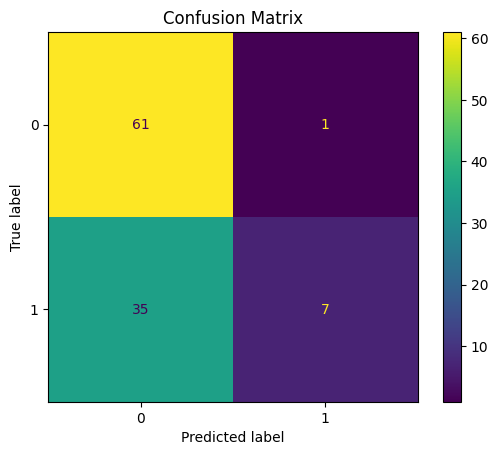

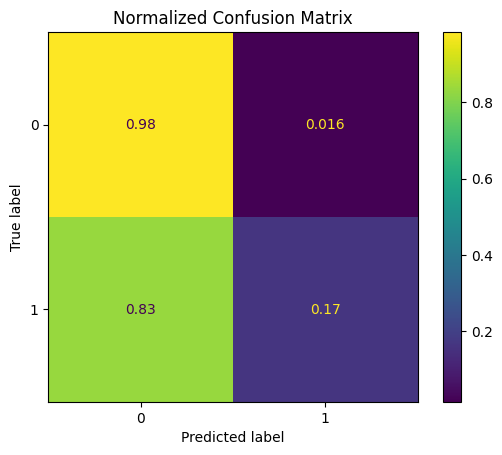

Log Loss:  0.6031351346923046


In [124]:
# Model predictions (probabilities)
Y_prob_resnet_3 = model_resnet_3.predict(X_test)

# Convert one-hot → class labels
Y_test_labels = y_test_encoded
Y_pred_resnet_3 = np.argmax(Y_prob_resnet_3, axis=1)

accuracy_model_resnet_3 = accuracy_score(Y_test_labels, Y_pred_resnet_3)
precision_model_resnet_3 = precision_score(Y_test_labels, Y_pred_resnet_3, average="weighted")
recall_score_model_resnet_3 = recall_score(Y_test_labels, Y_pred_resnet_3, average="weighted")
f1_score_model_resnet_3 = f1_score(Y_test_labels, Y_pred_resnet_3, average="weighted")

# Classification metrics (use labels)
print("Accuracy: ", accuracy_model_resnet_3)
print("Precision: ",precision_model_resnet_3)
print("Recall: ", recall_score_model_resnet_3)
print("F1 Score: ", f1_score_model_resnet_3)

# ROC AUC (multi-class, use probabilities)
roc_auc_mode_resnet_3 = roc_auc_score(
    y_test_encoded, 
    Y_prob_resnet_3[:,1]
)

print("ROC AUC Score: ", roc_auc_mode_resnet_3)

# Confusion Matrix
cm_resnet_3 = confusion_matrix(Y_test_labels, Y_pred_resnet_3)

ConfusionMatrixDisplay(confusion_matrix=cm_resnet_3).plot()
plt.title("Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    Y_test_labels,
    Y_pred_resnet_3,
    normalize="true"
)
plt.title("Normalized Confusion Matrix")
plt.show()
log_loss_model_resnet3 = log_loss(y_test_encoded, Y_prob_resnet_3)
# Log Loss (requires probabilities)
print("Log Loss: ", log_loss_model_resnet3)

The confusion matrix also shows quite good result. So overall for the Resnet Model the I selected here there are some characteristics: 
• Model architecture and layer configuration: the model one convolutional layesr, two residual blocks, two max-pooling layers, one fully connected hidden layers, an dropout layers and one output layer 
• Input dimensions: my input_shape is (64,64,3)
• Activation functions: relu
• Optimiser and learning rate: adam with its default learning rate of 0.0001 
• Batch size: 16
• Number of epochs: 30
• Data splits: training: 60%, validation: 20%, test: 20%
• Regularisation technique: 0.4
• Data augmentation methods: No

Mode3 3: Efficientnet In the next step, I will try efficient_net model. At first I will process the X_input

In [143]:
from tensorflow.keras.applications.efficientnet import preprocess_input
X_train_e = preprocess_input(X_train)
X_val_e = preprocess_input(X_val)

Then I run the efficient net model

In [152]:

efficient_net = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
efficient_net.trainable = False
model_net = keras.Sequential([
    efficient_net,
    keras.layers.GlobalAveragePooling2D(),  # Add a Flatten layer to reshape the output
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.5),  
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax'),
])
    
model_net.build((None, 64, 64, 3))
    

model_net.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



history = model_net.fit(X_train_e, y_train_encoded, batch_size = 32, epochs=20, validation_data=(X_val_e, y_val_encoded))

test_loss_net, test_acc_net= model_net.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_net)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.5113 - loss: 1.2059 - val_accuracy: 0.4519 - val_loss: 0.7262
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4598 - loss: 1.1346 - val_accuracy: 0.4519 - val_loss: 0.8069
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.4920 - loss: 0.9595 - val_accuracy: 0.4519 - val_loss: 0.8088
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5434 - loss: 0.9447 - val_accuracy: 0.4519 - val_loss: 0.7958
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5048 - loss: 0.9413 - val_accuracy: 0.4519 - val_loss: 0.8428
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5305 - loss: 0.9463 - val_accuracy: 0.4519 - val_loss: 0.7663
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4984 - loss: 0.9350 - val_accuracy: 0.4519 - val_loss: 0.7143
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4855 - loss: 0.9613 - val_accuracy: 0.4519 -

The accuracy is quite low at I see that probably I have quite many layers for my small dataset so I will try to reduce the number of layers 

In [153]:

efficient_net_1 = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
efficient_net_1.trainable = False
model_net_1 = keras.Sequential([
    efficient_net_1,
    keras.layers.GlobalAveragePooling2D(),  
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax'),
])
    
model_net_1.build((None, 64, 64, 3))
    

model_net_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



history = model_net_1.fit(X_train_e, y_train_encoded, batch_size = 32, epochs=20, validation_data=(X_val_e, y_val_encoded))

test_loss_net_1, test_acc_net_1= model_net_1.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_net_1)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.5177 - loss: 0.8894 - val_accuracy: 0.4519 - val_loss: 0.7381
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4630 - loss: 0.8974 - val_accuracy: 0.4519 - val_loss: 0.7424
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5273 - loss: 0.8424 - val_accuracy: 0.5481 - val_loss: 0.6900
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5048 - loss: 0.8474 - val_accuracy: 0.4519 - val_loss: 0.7035
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.5113 - loss: 0.7872 - val_accuracy: 0.5481 - val_loss: 0.6905
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5273 - loss: 0.7599 - val_accuracy: 0.4519 - val_loss: 0.7559
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5241 - loss: 0.7365 - val_accuracy: 0.4519 - val_loss: 0.7351
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5177 - loss: 0.7486 - val_accuracy: 0.4519 - 

So we can see that the accuracy did not change much, in the next step I use the original model with the learning rate to 0.0001

In [154]:

efficient_net_2 = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
efficient_net_2.trainable = False
model_net_2 = keras.Sequential([
    efficient_net_2,
    keras.layers.GlobalAveragePooling2D(),  # Add a Flatten layer to reshape the output
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.5),  
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax'),
])
    
model_net_2.build((None, 64, 64, 3))
    

model_net_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



history = model_net_2.fit(X_train_e, y_train_encoded, batch_size = 32, epochs=20, validation_data=(X_val_e, y_val_encoded))

test_loss_net_2, test_acc_net_2= model_net.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_net_2)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 689ms/step - accuracy: 0.4920 - loss: 1.1005 - val_accuracy: 0.5481 - val_loss: 0.6912
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4727 - loss: 1.0556 - val_accuracy: 0.4519 - val_loss: 0.6989
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5273 - loss: 0.9832 - val_accuracy: 0.4519 - val_loss: 0.7115
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5338 - loss: 1.0301 - val_accuracy: 0.4519 - val_loss: 0.7307
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5016 - loss: 1.0987 - val_accuracy: 0.4519 - val_loss: 0.7485
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.5273 - loss: 1.0413 - val_accuracy: 0.4519 - val_loss: 0.7551
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5209 - loss: 0.9933 - val_accuracy: 0.4519 - val_loss: 0.7565
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.4727 - loss: 1.0780 - val_accuracy: 0

The accuracy did not change much, in the next step I will use data augmentation 

In [155]:

efficient_net_aug = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
efficient_net_aug.trainable = False



train_generator_1 = datagen.flow(
    X_train,
    y_train_encoded,
    batch_size=64,
    shuffle=True
)
model_net_aug = keras.Sequential([
    efficient_net_aug,
    keras.layers.GlobalAveragePooling2D(),  # Add a Flatten layer to reshape the output
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.5),  
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),  
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax'),
])
    
model_net_aug.build((None, 64, 64, 3))
    

model_net_aug.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



history = model_net_aug.fit(train_generator_1, batch_size = 32, epochs=20, validation_data=(X_val_e, y_val_encoded))

test_loss_net_aug, test_acc_net_aug= model_net_aug.evaluate(X_test, y_test_encoded)

print("Test Accuracy:", test_acc_net_aug)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 684ms/step - accuracy: 0.5305 - loss: 1.0642 - val_accuracy: 0.5481 - val_loss: 0.6885
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.4727 - loss: 1.1771 - val_accuracy: 0.5481 - val_loss: 0.6890
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.4791 - loss: 1.1044 - val_accuracy: 0.5481 - val_loss: 0.6909
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.5498 - loss: 1.0215 - val_accuracy: 0.5481 - val_loss: 0.6930
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.5305 - loss: 1.0143 - val_accuracy: 0.4519 - val_loss: 0.6943
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.4823 - loss: 1.1452 - val_accuracy: 0.4519 - val_loss: 0.6964
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.5241 - loss: 0.9920 - val_accuracy: 0.4519 - val_loss: 0.6993
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.5145 - loss: 1.0523 - val_accuracy: 0.4519 - val_loss

So the accuracy of the model with data_augmentation is lower than the original. So for the Efficientnet model, we will use original. We evaluate this model 

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step
Accuracy:  0.5961538461538461
Precision:  0.35539940828402367
Recall:  0.5961538461538461
F1 Score:  0.4453197405004634
ROC AUC Score:  0.6136712749615976


C:\Users\vla\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


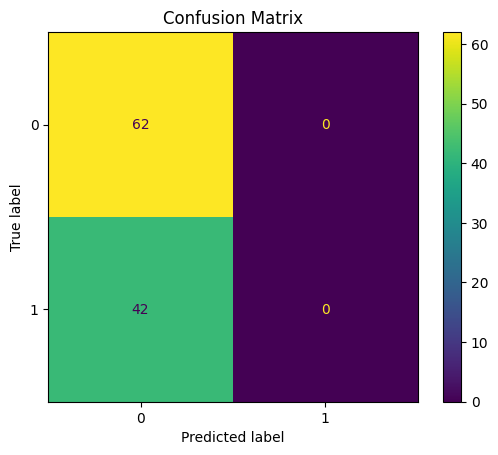

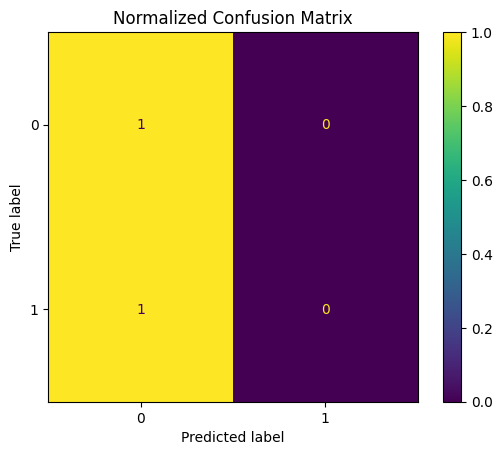

Log Loss:  0.6873155522542158


In [156]:
# Model predictions (probabilities)
Y_prob_net = model_net.predict(X_test)

# Convert one-hot → class labels
Y_test_labels = y_test_encoded
Y_pred_net = np.argmax(Y_prob_net, axis=1)

accuracy_model_net = accuracy_score(Y_test_labels, Y_pred_net)
precision_model_net = precision_score(Y_test_labels, Y_pred_net, average="weighted")
recall_score_model_net = recall_score(Y_test_labels, Y_pred_net, average="weighted")
f1_score_model_net = f1_score(Y_test_labels, Y_pred_net, average="weighted")

# Classification metrics (use labels)
print("Accuracy: ", accuracy_model_net)
print("Precision: ",precision_model_net)
print("Recall: ", recall_score_model_net)
print("F1 Score: ", f1_score_model_net)

# ROC AUC (multi-class, use probabilities)
roc_auc_net = roc_auc_score(
    y_test_encoded, 
    Y_prob_net[:,1]
)

print("ROC AUC Score: ", roc_auc_net)

# Confusion Matrix
cm_net = confusion_matrix(Y_test_labels, Y_pred_net)

ConfusionMatrixDisplay(confusion_matrix=cm_net).plot()
plt.title("Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    Y_test_labels,
    Y_pred_net,
    normalize="true"
)
plt.title("Normalized Confusion Matrix")
plt.show()
log_loss_net = log_loss(y_test_encoded, Y_prob_net)
# Log Loss (requires probabilities)
print("Log Loss: ", log_loss_net)

In [157]:
import pandas as pd

comparison_model = pd.DataFrame({
    "Models": ["CNN model", "Resnet Model", "Efficient_net Model"],

    "Tess loss": [
        test_loss,
        test_loss_resnet_3,
        test_loss_net
       
    ],

   
    "Test Accuracy": [
        test_acc,
        test_acc_resnet_3,
        test_acc_net
       
    ],

    "Precision": [
        precision_model,
        precision_model_resnet_3,
        precision_model_net
           
        ],
    
       
    "Recall": [
        recall_score_model,
        recall_score_model_resnet_3,
        recall_score_model_net
           
        ],

    "F1 score": [
        f1_score_model,
        f1_score_model_resnet_3,
        f1_score_model_net
               
            ],

    "ROC AUC Score": [
        roc_auc,
        roc_auc_mode_resnet_3,
        recall_score_model_net
               
            ],
    

    })
comparison_model



,Models,Tess loss,Test Accuracy,Precision,Recall,F1 score,ROC AUC Score
0,CNN model,0.552724,0.769231,0.777988,0.769231,0.771056,0.839094
1,Resnet Model,0.603135,0.653846,0.732171,0.653846,0.573398,0.845238
2,Efficient_net Model,0.687316,0.596154,0.355399,0.596154,0.445320,0.596154


Looking at the indicators above, we can see that CNN is the strongest model with highest accuracy, highest percision, highest recall , high F1 score and highest ROC AUC socre and low loss . One insights we can see from this is that even Resnet is more complicated than CNN model it does not neccessarily perform much better than CNN and even though Efficient_net is sophiticated model, it does not perform than these two for this particular dataset. 

I save the results of the comparison to an Excel file here 

In [132]:
comparison_model.to_csv(
    "comparison_model.csv",
    index=False
)

I save the final selected model here 

In [139]:
model.save("selected model.keras")

I also have the accuracy indicators of the selected model here 

In [141]:
import pandas as pd

selected_model_accuracy = pd.DataFrame({
    "Models": ["Resnet Model"],

    "Test loss": [
        
        test_loss
        
       
    ],

   
    "Test Accuracy": [
       
        test_acc
       
       
    ],

    "Precision": [
        
        precision_model
           
        ],
    
       
    "Recall": [
        
        recall_score_model
           
        ],

    "F1 score": [
      
        f1_score_model
               
            ],

    "ROC AUC Score": [
        
        roc_auc
               
            ],
    

    })
selected_model_accuracy


,Models,Test loss,Test Accuracy,Precision,Recall,F1 score,ROC AUC Score
0,Resnet Model,0.552724,0.769231,0.777988,0.769231,0.771056,0.839094


And I save the file for this accuracy here 

In [142]:
selected_model_accuracy.to_csv(
    "selected_model_accuracy.csv",
    index=False
)

Display and save the confusion matrix of the slection model

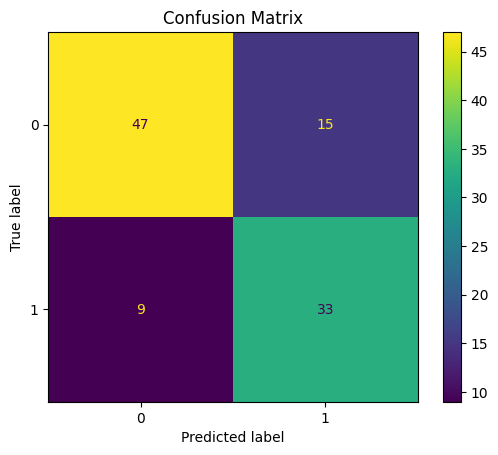

In [140]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Task 4: Critical reflection

The analysis of the model also show that: 
- The strength of the solution is that I compared three different models, namely CNN, Resnet and Efficientnet and in each model, I have four times I tried to fine-tune the model with different changes in the parameters, from the batch size, epoches, number of neurons, number of layers, activation, learning rate, early stopping to data augmentation. The selected model, therefore, is the result of the process of reviewing, testing and checking different models on the same dataset and I selected the one with the highest scores. I also evaluated the model on different scores: accuracy, loss, recall score, f1 score, et...so the comparision is quite broad.In the end I have a model with the accuracy nearly 80%, so I think it is quite a good results. 
- The limitation of the dataset: The dataset is quite small with only 519 images which might limit the effective applicaiton of some sophiticated models, and the images are more in the dark side of the band, so it can be a downside when analysing the images. Another limitation is that the images are under RGB, which will limit the model choice that can work with this image format. If the images are satelites with different possible layers of the images, we can more sophiticated and more accurate models  
- Limitationof the developed model:The confusion matrix shows that the selected model still have a part of the images are predicted wrongly even the Resnet model is quite complicated. 
- Challenges during the experiments: I would need to convert the images into the same types of imges and dimensions. I also need to encode the Y variable to make them more standardised. During the experiment, I can see that not all the time the changes of the learning rates or the data augmentation can help to improve the model, like for the case of CNN in the end I chose to use the original model. Of course, fine-tuning worked for Resnet and Efficient_net which in the end I use the fine_tuning model, not the original one. However, I also can see that it is not easy to find the best combination of fine_tuning when I did it manually, so for future similar practice, probably a more comprehensive way and code to check all these possible combination can help to produce better models. Another challenge is when I devided the data into train, val and test, to make sure the logics of choosing the model make sense, I need to make sure the spilitting is fixed with the sample, but again with all many times of testing different models, make sure that the data is producible the same among many code blocks put also a challange for manage the codes. Another thing is that even though I have the samples fixed, I can see that to control the sampples for Resnet and Efficientnet model is not easy so everytime I run these models, the results can be different. That is the tricky part and that would be space to improve for this experiment.For Efficientnet model, probably due to the small dataset, the accuracy did not change much with the finetuning 
- Computational and resources considerations: I can see that with all my testing and fine-tuning, the model I selected in the end is just a little better then the first one CNN that I tried (0.80 vs 0.76), so the question is if all the testing and fine-tuning is worth it. Also even though the dataset is quite small, I can see that it still needs time for computer to run the model. Imagine we have a bigger dataset, which I think often is more of the reality, we are talkign about thousands and millison of dataset, how much engery and computer capacity must be devoted to that. 
- Environmental, societal and ethical implications of automated vegetation classification: I think the good side of having a model like this is taht we can have a very quick identification of the areas with the Kahikatea tree, so that we can decide what we will do that eares regarding environment and ecological activities and investment, etc...But also there are some ethical consideration with it. First, every model is not correct 100%, there are a chance that the model miss some and in the case, our model missed some images due to small dataset, so the question is what would be the cases of wrongly identified. Those areas might miss some oppotunities, etc...and in the end it is not fair. We might miss some areas that the trees are very small and cannot be captured by the satelite too. The second ethical consideration is the final purpose of the classification, data scientist with the help of computers, can do very quickly to classify thing but I am not sure if they have all information on the final use of that information, let's say if the classification of those images led to the evacuation of a resident areas, the trees cutting in that areas, this is just a tree image classification example, but let's say about the case of people detecting or classification, it will put more ethical concerns on the job. 
- Opportunities for future improvement and extension: I think the model development will work better with a bigger dataset, better quality of the images, images with better formats. We can have a more comprehensive way to check different parameters combination, so we can choose the best one. We can also try more models, given that here we only try three models. We can also use human information to validate and test some data as well as we can use images not from the dataset to test them  

